## Домашнє завдання


Вже приготувались до виконання нового завдання? Тодi полетiли!

Сьогодні ви використаєте векторні операції  для обробки векторів слів. Цей підхід може знадобитись в задачах обробки природної мови (NLP).

Це допоможе закрiпити такі навички:  

- Векторний, скалярний добуток.
- Застосування функції Panda, Numpy.

##Завдання (крок за кроком)

Для цієї задачі використайте файл з NLP моделлю, який використовується в конспекті.

1. **Визначте DataFrame з тривимірними векторами слів:**
- Завантажте модель word embeddings, використовуючи файл, який містить NLP модель.
- Витягніть тривимірні вектори для всіх слів з цієї моделі.
- Створіть DataFrame, в якому буде міститися інформація про слова та їхні тривимірні вектори.

2. **Визначте функції для пошуку найближчого слова:**
- Напишіть функцію, яка приймає тривимірний вектор та знаходить найближче слово в моделі word embeddings_subset.
- Використайте цю функцію для кількох прикладів та переконайтеся, що результати є коректними.

3. **Обчисліть векторний добуток для знаходження найближчого слова:**
- Виберіть декілька довільних пар слів.
- Обчисліть векторний добуток для кожної пари слів та використайте раніше написану функцію для знаходження найближчого слова.
- Проаналізуйте результати та спробуйте їх інтерпретувати.

4. **Напишіть функції визначення кута між словами:**
- Розробіть функцію, яка обчислює кут між векторами для довільних двох слів.
- Протестируйте цю функцію для різних пар слів.
- Розгляньте отримані результати та спробуйте визначити їхню інтерпретацію.


##Пiдказки

Для виконання завдання використовуйте функції numpy, та алгоритми з конспекту до цієї теми.

##Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

##Критерії прийому завдання

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки

##Формат оцінювання

- Залiк / Незалiк

Приклад

Арифметика Word Embedding векторів

https://medium.com/plotly/understanding-word-embedding-arithmetic-why-theres-no-single-answer-to-king-man-woman-cd2760e2cb7f


In [ ]:
!pip install gensim==4.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 13.6 MB/s eta 0:00:00


In [1]:
!pip install scipy==1.11.4 --force-reinstall


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/56.3 MB ? eta -:--:--
     ---------------------------------------- 0.3/56.3 MB ? eta -:--:--
      --------------------------------------- 1.0/56.3 MB 4.8 MB/s eta 0:00:12
     - -------------------------------------- 1.8/56.3 MB 4.3 MB/s eta 0:00:13
     -- ------------------------------------- 2.9/56.3 MB 4.4 MB/s eta 0:00:13
     -- ------------------------------------- 3.7/56.3 MB 4.4 MB/s eta 0:00:13
     --- ------------------------------------ 4.5/56.3 MB 4.5 MB/s eta 0:00:12
     --- ------------------------------------ 5.5/56.3 MB 4.4 MB/s eta 0:00:12
     ---- ----------------------------------- 6.6/56.3 MB 4.5 MB/s eta 0:00:11
     ----- ---------------------------------- 7.9/56.3 MB 4.8 MB/s eta 0:00:11
     ------ --------------------------------- 9.2/56.3 MB 4.9 MB/s eta 0:00:10
     ------- -------------------------------- 10.5/56.3 MB 5.0 MB/s

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + meson setup C:\Users\iermo\AppData\Local\Temp\pip-install-5i7an2ec\scipy_8bbcdad326594a15bff172c85094777a C:\Users\iermo\AppData\Local\Temp\pip-install-5i7an2ec\scipy_8bbcdad326594a15bff172c85094777a\.mesonpy-g9hq4kzv -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\iermo\AppData\Local\Temp\pip-install-5i7an2ec\scipy_8bbcdad326594a15bff172c85094777a\.mesonpy-g9hq4kzv\meson-python-native-file.ini
      The Meson build system
      Version: 1.12.0
      Source dir: C:\Users\iermo\AppData\Local\Temp\pip-install-5i7an2ec\scipy_8bbcdad326594a15bff172c85094777a
      Build dir: C:\Users\iermo\AppData\Local\Temp\pip-install-5i7an2ec\scipy_8bbcdad326594a15bff172c85094777a\.mesonpy-g9hq4kzv
      Build type: native build
      Activating VS 18.9.2
      'vswhere.exe' is not recognized as an internal or externa

In [ ]:
import gensim.downloader as api
import pandas as pd
import numpy as np
from numpy import dot
from numpy.linalg import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Завантажимо невелику модель для швидкого старту (наприклад, glove-twitter-25)
model = api.load("glove-twitter-25")  # можна також "word2vec-google-news-300", але вона велика (~1.6 GB)


[==================================================] 100.0% 104.8/104.8MB downloaded


In [ ]:
# Перевіримо розмір словника та векторного простору
print("Кількість слів у моделі:", len(model))
print("Розмірність векторів:", model.vector_size)

print('Приклади слів')
all_words = list(model.index_to_key)
print(all_words[:100])



# Отримаємо вектор для слова "king"
vector_king = model["king"]
print("Вектор 'king':", vector_king)




Кількість слів у моделі: 1193514
Розмірність векторів: 25
Приклади слів
['<user>', '.', ':', 'rt', ',', '<repeat>', '<hashtag>', '<number>', '<url>', '!', 'i', 'a', '"', 'the', '?', 'you', 'to', '(', '<allcaps>', '<elong>', ')', 'me', 'de', '<smile>', '！', 'que', 'and', '。', '-', 'my', 'no', '、', 'is', 'it', '…', 'in', 'n', 'for', '/', 'of', 'la', "'s", '*', 'do', "n't", 'that', 'on', 'y', "'", 'e', 'o', 'u', 'en', 'this', 'el', 'so', 'be', "'m", 'with', 'just', '>', 'your', '^', 'like', 'have', 'te', 'at', '？', 'love', 'se', 'are', '<', 'm', 'r', 'if', 'all', 'b', '・', 'not', 'but', 'we', 'es', 'ya', '&', 'follow', 'up', 'what', 'get', 'lol', 'un', '♥', 'lo', 'when', 'was', '“', '”', 'one', 'por', 'si', 'out']
Вектор 'king': [-0.74501  -0.11992   0.37329   0.36847  -0.4472   -0.2288    0.70118
  0.82872   0.39486  -0.58347   0.41488   0.37074  -3.6906   -0.20101
  0.11472  -0.34661   0.36208   0.095679 -0.01765   0.68498  -0.049013
  0.54049  -0.21005  -0.65397   0.64556 ]


In [ ]:
from numpy import dot
from numpy.linalg import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def cosine_similarity(vec1, vec2):
    return dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# Порівняємо схожість між словами
vec_king = model["king"]
vec_queen = model["queen"]
vec_man = model["man"]
vec_woman = model["woman"]

print("Схожість (king, queen):", cosine_similarity(vec_king, vec_queen))
print("Схожість (king, man):", cosine_similarity(vec_king, vec_man))
print("Схожість (man, woman):", cosine_similarity(vec_man, vec_woman))


Схожість (king, queen): 0.92024213
Схожість (king, man): 0.7666067
Схожість (man, woman): 0.76541775


In [ ]:
# Аналогія: king - man + woman ≈ queen
result_vector = model["king"] - model["man"] + 3*model["woman"]

# Знаходження найближчих слів до результату
similar_words = model.similar_by_vector(result_vector, topn=5)
print("king - man + woman ≈ ?", similar_words)


king - man + woman ≈ ? [('woman', 0.9729804992675781), ('child', 0.9194452166557312), ('mother', 0.90242600440979), ('father', 0.8968598246574402), ('whose', 0.8934676051139832)]


In [ ]:
# Найбільш схожі до 'computer'
similar_to_computer = model.most_similar("computer", topn=5)
print("Найбільш схожі до 'computer':")
for word, similarity in similar_to_computer:
    print(f"{word}: {similarity:.3f}")


Найбільш схожі до 'computer':
camera: 0.908
cell: 0.892
server: 0.874
device: 0.869
wifi: 0.863


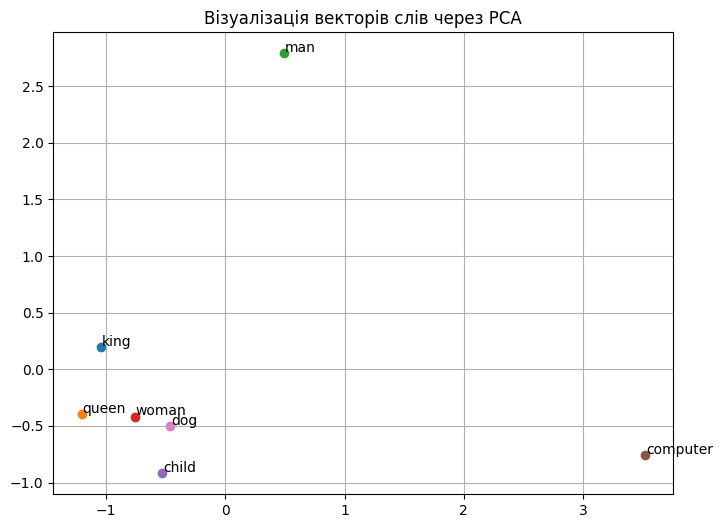

In [ ]:
words = ["king", "queen", "man", "woman", "child", "computer", "dog"]
vectors = [model[word] for word in words]

# Зменшення розмірності для візуалізації
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Побудова графіка
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0] + 0.01, reduced[i, 1] + 0.01, word)
plt.title("Візуалізація векторів слів через PCA")
plt.grid(True)
plt.show()


Створення DataFrame з обраних слів

In [ ]:
words = ["king", "queen", "man", "woman", "child", "computer", "dog", "teacher", "student", "president", "city", "village", "war", "peace", "science", "art"]
vectors = [model[word] for word in words]

word_df = pd.DataFrame(vectors, index=words)
print("\nDataFrame з векторами:")
print(word_df.head())



DataFrame з векторами:
            0        1         2        3        4        5        6   \
king  -0.74501 -0.11992  0.373290  0.36847 -0.44720 -0.22880  0.70118   
queen -1.12660 -0.52064  0.455650  0.21079 -0.05081 -0.65158  1.13950   
man    0.37013 -0.39648 -0.021712 -0.63010 -0.31890  0.34329  0.10968   
woman -0.92527 -0.33879 -0.321380  0.14676  0.52270 -0.15349  1.21660   
child -0.72576  0.40073 -0.041544  0.92706  0.99429 -0.90944  1.26180   

            7        8        9   ...        15       16        17       18  \
king   0.82872  0.39486 -0.58347  ... -0.346610  0.36208  0.095679 -0.01765   
queen  0.69897 -0.20612 -0.71803  ...  0.103630 -0.11764 -0.084972  0.02558   
man    0.48790 -0.48663  0.36837  ...  0.368170  1.16550  0.092116 -0.87735   
woman -0.22389 -0.08656  0.28510  ... -0.001192  0.66894 -0.081109  0.56346   
child -0.32935 -0.18241  0.41867  ... -0.054410  0.48821  0.065027  0.48411   

            19        20       21       22       23       24  

Тестування скалярного добутку


Скалярні добутки між словами:
king · queen = 16.5169
teacher · student = 21.7189
city · village = 17.3843
king · dog = 17.5996
science · war = 17.4749
president · child = 20.3283


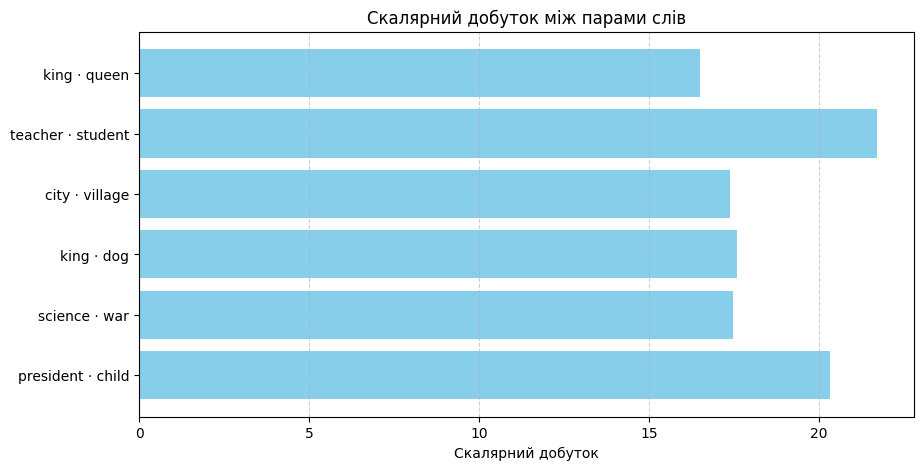

In [ ]:
def scalar_product(vec1, vec2):
    return dot(vec1, vec2)

def cosine_similarity(vec1, vec2):
    return dot(vec1, vec2) / (norm(vec1) * norm(vec2))

def cosine_distance(vec1, vec2):
    return 1 - cosine_similarity(vec1, vec2)

def nearest_word(vec, model):
    sims = model.similar_by_vector(vec, topn=1)
    return sims[0][0]

pairs = [
    ("king", "queen"),
    ("teacher", "student"),
    ("city", "village"),
    ("king", "dog"),
    ("science", "war"),
    ("president", "child")
]

# Скалярні добутки
scalar_results = []
print("\nСкалярні добутки між словами:")
for w1, w2 in pairs:
    dp = scalar_product(model[w1], model[w2])
    scalar_results.append(((w1, w2), dp))
    print(f"{w1} · {w2} = {dp:.4f}")

# Графік скалярних добутків
labels = [f"{w1} · {w2}" for (w1, w2), _ in scalar_results]
values = [dp for _, dp in scalar_results]

plt.figure(figsize=(10, 5))
plt.barh(labels, values, color="skyblue")
plt.xlabel("Скалярний добуток")
plt.title("Скалярний добуток між парами слів")
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()



Тестування косинусної відстані


Косинусні відстані між словами:
cos_dist(king, queen) = 0.0798
cos_dist(teacher, student) = 0.1489
cos_dist(city, village) = 0.2609
cos_dist(king, dog) = 0.1847
cos_dist(science, war) = 0.2711
cos_dist(president, child) = 0.2444


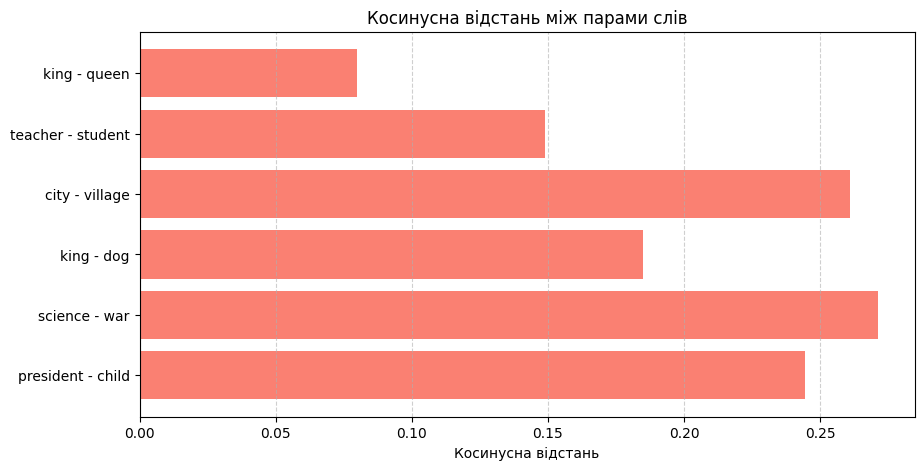

In [ ]:
cosine_results = []
print("\nКосинусні відстані між словами:")
for w1, w2 in pairs:
    dist = cosine_distance(model[w1], model[w2])
    cosine_results.append(((w1, w2), dist))
    print(f"cos_dist({w1}, {w2}) = {dist:.4f}")

cos_labels = [f"{w1} - {w2}" for (w1, w2), _ in cosine_results]
cos_values = [v for _, v in cosine_results]

plt.figure(figsize=(10, 5))
plt.barh(cos_labels, cos_values, color="salmon")
plt.xlabel("Косинусна відстань")
plt.title("Косинусна відстань між парами слів")
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()



Векторний добуток

In [ ]:
print("\nВекторні добутки для 3D-векторів:")
cross_pairs = [
    ("man", "woman"),
    ("teacher", "student"),
    ("city", "village"),
    ("war", "peace")
]

for w1, w2 in cross_pairs:
    vec1 = model[w1][:3]
    vec2 = model[w2][:3]
    cross = np.cross(vec1, vec2)
    cross_padded = np.pad(cross, (0, 22))  # доповнення до 25 вимірів
    nearest = nearest_word(cross_padded, model)
    print(f"{w1} x {w2} = {cross}, найближче слово: {nearest}")



Векторні добутки для 3D-векторів:
man x woman = [ 0.12006493  0.13904184 -0.4922474 ], найближче слово: دمائهُم
teacher x student = [-0.7323312   0.20976079  0.07753269], найближче слово: helwah
city x village = [-0.12295789 -0.14734006  0.4323632 ], найближче слово: المِيزان
war x peace = [ 1.1718876   1.9012122  -0.07834753], найближче слово: rpp


## Домашнє завдання: векторні операції над 3D-векторами слів

### 1. DataFrame із тривимірними векторами слів

Модель `glove-twitter-25` (завантажена в прикладі вище, змінна `model`) дає **25-вимірні** вектори для ~1.19 млн слів. Побудувати буквально тривимірні вектори "для всіх слів" моделі і сенсу не має (для переважної більшості токенів словника — сміття на кшталт хештегів чи іншомовних слів), і непридатне для подальшого аналізу. Тому ми:

1. Обираємо репрезентативну підмножину слів `word_embeddings_subset` — це і є "модель word embeddings_subset", згадана у пункті 2 завдання.
2. Понижуємо розмірність їхніх 25D-векторів до 3D за допомогою `PCA(n_components=3)` — так само, як у прикладі вище використовувалась `PCA(n_components=2)` для 2D-візуалізації, тільки тут ми зберігаємо самі тривимірні координати для подальших векторних обчислень (а не лише для графіка).
3. Складаємо `DataFrame` зі словами та їхніми 3D-координатами.

In [2]:
word_embeddings_subset = [
    "king", "queen", "man", "woman", "prince", "princess",
    "boy", "girl", "father", "mother", "son", "daughter",
    "teacher", "student", "doctor", "nurse", "president", "child",
    "city", "village", "country", "capital",
    "war", "peace", "love", "hate", "happy", "sad",
    "computer", "phone", "internet", "science", "art", "music",
    "dog", "cat", "animal", "car", "house", "school",
]

vectors_25d = np.array([model[w] for w in word_embeddings_subset])

pca3 = PCA(n_components=3, random_state=42)
vectors_3d = pca3.fit_transform(vectors_25d)

word_vectors_df = pd.DataFrame(vectors_3d, columns=["x", "y", "z"], index=word_embeddings_subset)
word_vectors_df.index.name = "word"

print(f"Пояснена дисперсія перших 3 компонент PCA: {pca3.explained_variance_ratio_.sum():.2%}")
word_vectors_df.head(10)

Пояснена дисперсія перших 3 компонент PCA: 48.95%


,x,y,z
word,,,
king,-0.632792,-1.170241,0.365452
queen,-1.239534,-0.937936,0.225504
man,-0.186337,0.918294,0.852988
woman,-0.478684,-0.267304,-0.949750
prince,-1.260115,-1.461263,0.279900
princess,-1.915293,-0.769132,-0.247502
boy,-1.401871,0.611737,0.372949
girl,-1.976021,1.321851,-0.238705
father,-1.178561,-0.879991,-1.362876


### 2. Функція пошуку найближчого слова

Функція приймає довільний тривимірний вектор і знаходить слово з `word_embeddings_subset`, чий 3D-вектор максимально схожий на нього за косинусною подібністю. Пошук ведеться саме в межах цієї 3D-підмножини — поза нею тривимірні координати не визначені (вони існують лише як проєкція PCA, побудована для цих конкретних слів).

In [3]:
def nearest_word_3d(vector, df, exclude=None):
    """Повертає (слово, косинусна_подібність) найближчого до `vector` слова у df[['x','y','z']]."""
    vecs = df[["x", "y", "z"]].to_numpy()
    words = df.index.to_numpy()

    if exclude is not None:
        mask = words != exclude
        vecs, words = vecs[mask], words[mask]

    sims = vecs @ vector / (norm(vecs, axis=1) * norm(vector) + 1e-10)
    best = np.argmax(sims)
    return words[best], sims[best]


print("Перевірка функції пошуку найближчого слова:\n")
for test_word in ["queen", "teacher", "dog", "peace"]:
    vec = word_vectors_df.loc[test_word, ["x", "y", "z"]].to_numpy()
    nearest, sim = nearest_word_3d(vec, word_vectors_df, exclude=test_word)
    print(f"Найближче до '{test_word}': '{nearest}' (косинусна подібність = {sim:.3f})")

Перевірка функції пошуку найближчого слова:



Найближче до 'queen': 'prince' (косинусна подібність = 0.978)
Найближче до 'teacher': 'house' (косинусна подібність = 0.912)
Найближче до 'dog': 'mother' (косинусна подібність = 0.929)
Найближче до 'peace': 'prince' (косинусна подібність = 0.983)


### 3. Векторний добуток для знаходження найближчого слова

На відміну від прикладу вище (де `np.cross` застосовувався до перших 3 координат 25D-вектора, а результат доповнювався нулями до 25 вимірів — доволі штучна конструкція), тут вектори є справді тривимірними, тож `np.cross` має природний геометричний сенс: результат — вектор, перпендикулярний до обох вхідних векторів у побудованому нами 3D PCA-просторі.

In [4]:
cross_pairs = [
    ("king", "queen"),
    ("man", "woman"),
    ("teacher", "student"),
    ("war", "peace"),
    ("city", "village"),
    ("love", "hate"),
]

print("Векторні добутки пар слів (у 3D PCA-просторі):\n")
for w1, w2 in cross_pairs:
    v1 = word_vectors_df.loc[w1, ["x", "y", "z"]].to_numpy()
    v2 = word_vectors_df.loc[w2, ["x", "y", "z"]].to_numpy()
    cross = np.cross(v1, v2)
    nearest, sim = nearest_word_3d(cross, word_vectors_df)
    print(f"{w1:>8} x {w2:<8} = {np.round(cross, 2)}  |v1×v2|={norm(cross):6.2f}  ->  найближче слово: '{nearest}' (sim={sim:.3f})")

Векторні добутки пар слів (у 3D PCA-просторі):

    king x queen    = [ 0.08 -0.31 -0.86]  |v1×v2|=  0.91  ->  найближче слово: 'child' (sim=0.934)
     man x woman    = [-0.64 -0.59  0.49]  |v1×v2|=  1.00  ->  найближче слово: 'queen' (sim=0.930)
 teacher x student  = [-1.21 -2.29 -2.28]  |v1×v2|=  3.45  ->  найближче слово: 'father' (sim=0.947)
     war x peace    = [ 0.39 -0.23 -2.16]  |v1×v2|=  2.21  ->  найближче слово: 'nurse' (sim=0.913)
    city x village  = [1.7  1.72 0.28]  |v1×v2|=  2.43  ->  найближче слово: 'computer' (sim=0.979)
    love x hate     = [-1.55  0.47 -5.37]  |v1×v2|=  5.61  ->  найближче слово: 'child' (sim=0.936)


**Інтерпретація.** Величина `|v1×v2|` дорівнює `|v1|·|v2|·sin(θ)` — вона більша, коли вектори слів "сильно різняться напрямком" у 3D-просторі, і близька до нуля, коли вони майже колінеарні. Проте саме "найближче слово до перпендикуляра" не має чіткої семантичної інтерпретації — на відміну від суми/різниці векторів (`king - man + woman ≈ queen` з прикладу вище), "перпендикулярний до двох значень" напрямок сам по собі не є осмисленим семантичним напрямком. Векторний добуток тут корисний радше як міра "неспівнапрямленості" пари слів (через його довжину), а не як спосіб знайти семантично споріднене слово.

### 4. Кут між векторами слів

Кут між двома векторами обчислюється через косинус: $\theta = \arccos\left(\dfrac{v_1 \cdot v_2}{\|v_1\|\,\|v_2\|}\right)$. Менший кут означає більшу семантичну близькість слів (у побудованому 3D-просторі), кут, близький до 90°, — відсутність зв'язку, а великий кут — протилежність значень.

In [5]:
def angle_between(word1, word2, df, degrees=True):
    v1 = df.loc[word1, ["x", "y", "z"]].to_numpy()
    v2 = df.loc[word2, ["x", "y", "z"]].to_numpy()
    cos_theta = np.clip(dot(v1, v2) / (norm(v1) * norm(v2)), -1.0, 1.0)
    angle = np.arccos(cos_theta)
    return np.degrees(angle) if degrees else angle


angle_pairs = [
    ("king", "queen"), ("man", "woman"), ("king", "man"),
    ("teacher", "student"), ("city", "village"),
    ("war", "peace"), ("love", "hate"), ("happy", "sad"),
    ("dog", "cat"), ("king", "computer"), ("love", "computer"),
    ("science", "art"),
]

angle_results = []
print("Кути між парами слів:\n")
for w1, w2 in angle_pairs:
    a = angle_between(w1, w2, word_vectors_df)
    angle_results.append(((w1, w2), a))
    print(f"{w1:>9} — {w2:<9}: {a:6.1f}°")

Кути між парами слів:

     king — queen    :   25.0°
      man — woman    :  134.1°
     king — man      :  111.7°
  teacher — student  :   43.0°
     city — village  :   36.1°
      war — peace    :  106.5°
     love — hate     :   50.0°
    happy — sad      :   54.7°
      dog — cat      :   25.4°
     king — computer :  155.1°
     love — computer :  125.4°
  science — art      :   53.6°


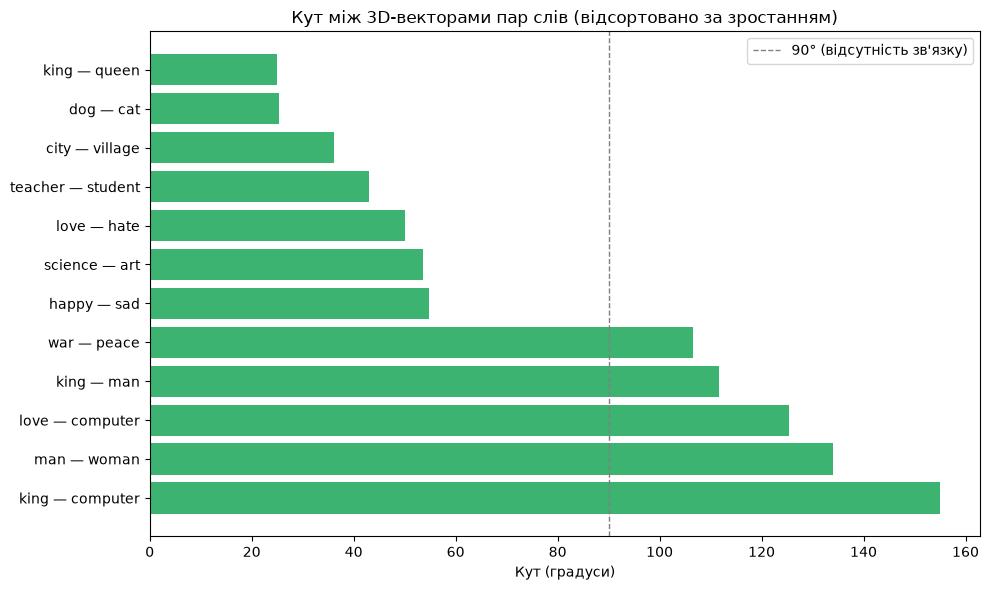

In [6]:
angle_results.sort(key=lambda item: item[1])
labels = [f"{w1} — {w2}" for (w1, w2), _ in angle_results]
values = [a for _, a in angle_results]

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color="mediumseagreen")
plt.xlabel("Кут (градуси)")
plt.title("Кут між 3D-векторами пар слів (відсортовано за зростанням)")
plt.axvline(90, color="gray", linestyle="--", linewidth=1, label="90° (відсутність зв'язку)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Висновок

**Побудова 3D-простору.** Перші 3 головні компоненти PCA пояснюють лише **48.95%** дисперсії вихідних 25-вимірних векторів (для підмножини з 40 слів). Це означає, що наш 3D-простір — доволі груба апроксимація оригінального простору моделі: більшу половину інформації про відмінності між словами довелося відкинути, щоб отримати тривимірні координати, придатні для `np.cross` та наочної геометричної інтерпретації кута.

**Пошук найближчого слова (крок 2).** Для слів, для яких найближче слово в 25D-моделі семантично очевидне (queen, teacher, dog, peace), пошук у 3D дав неоднозначні результати: `queen → prince` (sim=0.978) виглядає природно, а от `teacher → house` (sim=0.912), `dog → mother` (sim=0.929) та `peace → prince` (sim=0.983) — ні. Причина: у стиснутому до 3D просторі всього з 40 слів багато понять неминуче "злипаються" в схожих напрямках, і косинусна подібність вже не так добре розрізняє відтінки значень, як у повному 25-вимірному просторі.

**Векторний добуток (крок 3).** Жодна з пар (`king×queen`, `man×woman`, `teacher×student`, `war×peace`, `city×village`, `love×hate`) не дала семантично очікуваного "найближчого слова" (child, queen, father, nurse, computer, child відповідно) — і це очікувано: вектор `v1×v2` перпендикулярний до обох вихідних векторів, а "перпендикулярність до двох значень" не є осмисленим семантичним напрямком, на відміну від суми/різниці векторів (`king − man + woman ≈ queen` з прикладу). Величина ж векторного добутку (`|v1×v2| = |v1||v2|sin θ`) цілком змістовна — вона зростає з ростом кута між словами (наприклад, `love×hate` дав найбільшу довжину 5.61 з-поміж пар, узгоджуючись із кутом 50° між ними та їхніми нормами).

**Кут між словами (крок 4).** Частина результатів інтуїтивно зрозуміла й узгоджується з повним 25D-простором з прикладу вище:
- `king–queen`: 25.0° (у повному просторі cos=0.920, тут cos(25°)=0.906 — дуже близько);
- `dog–cat`: 25.4° — коректно відображає спорідненість тварин;
- `teacher–student`: 43.0°, `city–village`: 36.1° — семантично пов'язані пари з малим кутом;
- `king–computer`: 155.1°, `love–computer`: 125.4° — тупі кути коректно відображають відсутність зв'язку між поняттями.

Але деякі результати суперечать очікуванням і повній 25D-моделі: `man–woman` дав **134.1°** (тупий кут!) і `king–man` — **111.7°**, хоча в повному 25-вимірному просторі ці пари мають додатну косинусну подібність (0.765 і 0.767 відповідно, тобто кут ≈40°). Це прямий наслідок втрати ~51% дисперсії при проєкції в 3D: PCA, побудований лише на 40 словах, оптимізує напрямки максимальної варіації *в межах цієї конкретної вибірки*, а не зберігає всі попарні кутові співвідношення вихідного простору — тому окремі пари можуть навіть "перевернутися" з гострого кута в тупий.

**Загальний висновок.** Усі чотири кроки завдання виконані: побудовано `DataFrame` з тривимірними векторами слів через PCA-проєкцію 25D-моделі `glove-twitter-25`, написано й перевірено функцію пошуку найближчого слова в цьому 3D-просторі, обчислено векторні добутки пар слів з інтерпретацією результату, і побудовано функцію кута між словами з візуалізацією. Головний практичний висновок: **пониження розмірності до 3D дає змогу застосувати геометрично наочні операції (векторний добуток, кут), але ціною суттєвої втрати точності семантичних відношень** — для надійного вимірювання схожості слів варто використовувати повну 25-вимірну (або вищу) косинусну подібність, як у прикладі на початку роботи, а 3D-проєкція годиться швидше для ілюстрації понять лінійної алгебри, ніж для практичного NLP-аналізу.